## TASK 1

Analysis of this project

In [61]:

! pip install pandas numpy matplotlib seaborn nltk scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [62]:
data = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

In [63]:
data.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [64]:
data.shape

(1407328, 6)

In [65]:
data.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [66]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [67]:
data.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [68]:
data.duplicated().sum()

np.int64(0)

## DESCRIPTIVE STATISTICS 

In [69]:
headline_length = data['headline']

# Character Count within each headline
data['headline_length'] = headline_length.astype(str).apply(len)

#Headline Statistics
data['headline_length'].describe()



count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [70]:
# Word Count within each headline
data['headline_word_count'] = headline_length.astype(str).apply(
    lambda x : len(x.split())
)

data['headline_word_count'].describe()

count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: headline_word_count, dtype: float64

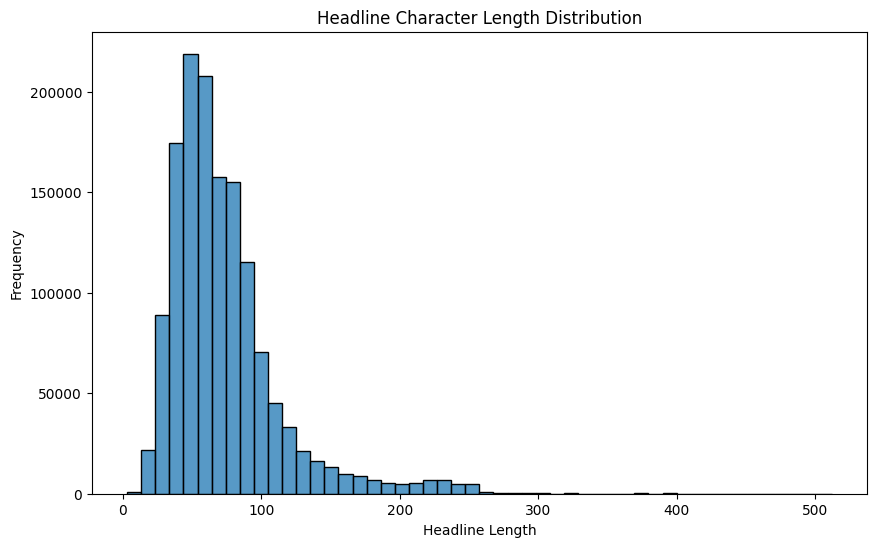

In [71]:
plt.figure(figsize=(10,6))
sns.histplot(data['headline_length'], bins=50)

plt.title("Headline Character Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

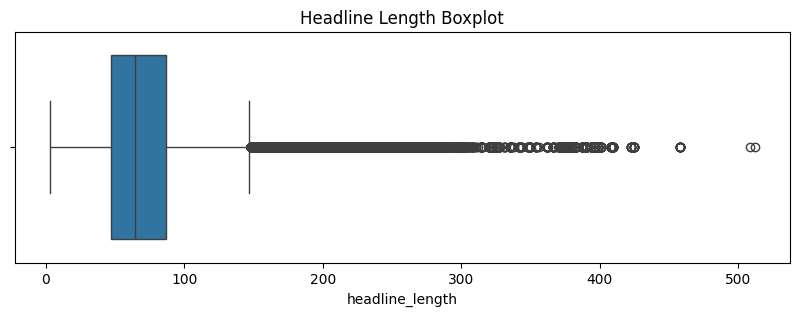

In [72]:
plt.figure(figsize=(10,3))
sns.boxplot(x=data['headline_length'])

plt.title("Headline Length Boxplot")

plt.show()


In [73]:
# Articles Per Publisher 

publisher_count = data['publisher'].value_counts()
print("Topp 10 Publisher")
publisher_count.head(10)

Topp 10 Publisher


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

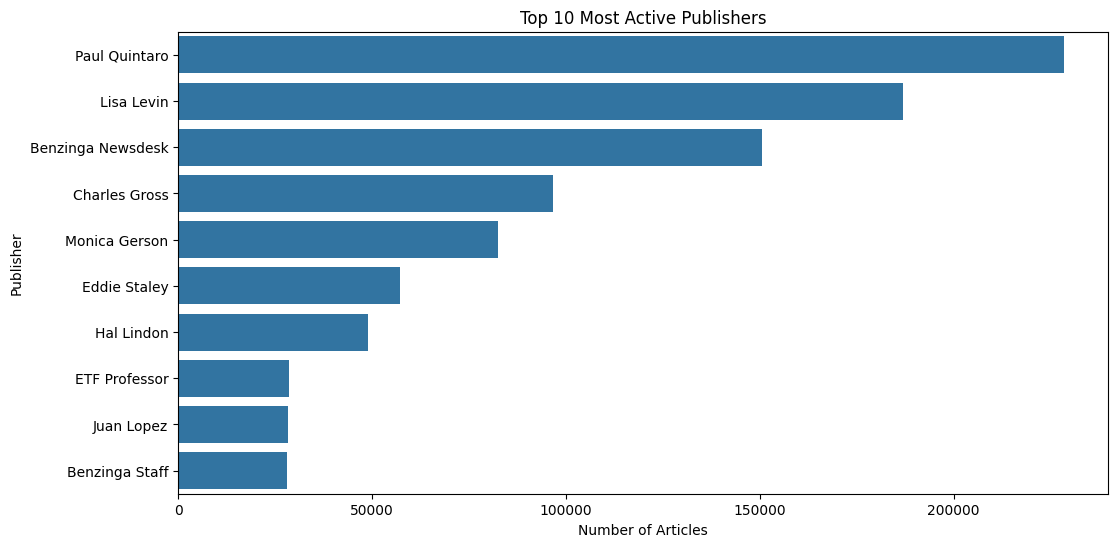

In [74]:
top_publisher = publisher_count.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_publisher.values,
    y=top_publisher.index
)

plt.title("Top 10 Most Active Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

In [75]:
# Articles Per Stock

stock_counts = data['stock'].value_counts()

print("Top 10 Stocks")
stock_counts.head(10)

Top 10 Stocks


stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

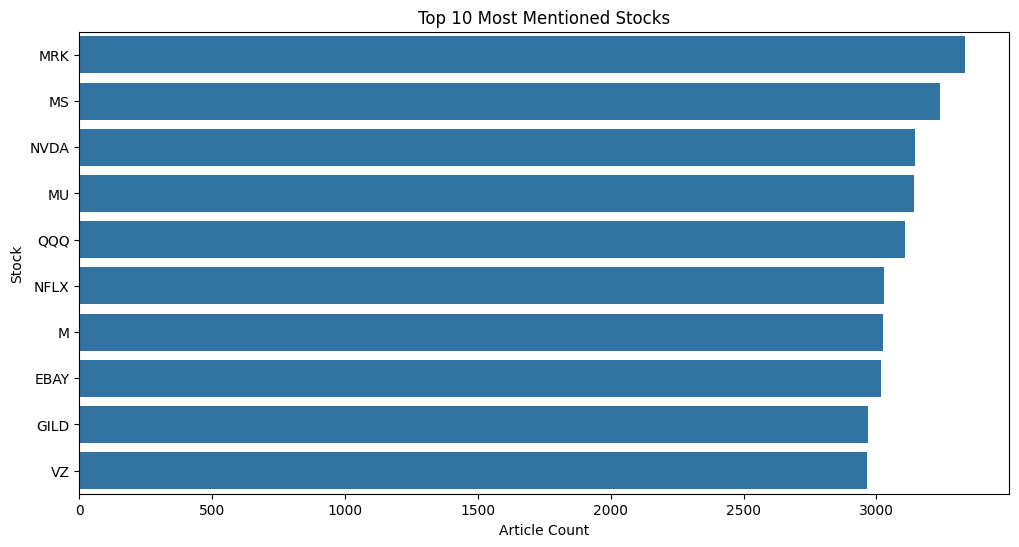

In [76]:
top_stocks = stock_counts.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stocks.values,
    y=top_stocks.index
)

plt.title("Top 10 Most Mentioned Stocks")
plt.xlabel("Article Count")
plt.ylabel("Stock")

plt.show()

In [77]:
# Publication Trend Over Time
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['publication_day'] = data['date'].dt.date

daily_articles = data.groupby('publication_day').size()

print("\nDaily Publication Trend")
print(daily_articles.head())


Daily Publication Trend
publication_day
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64


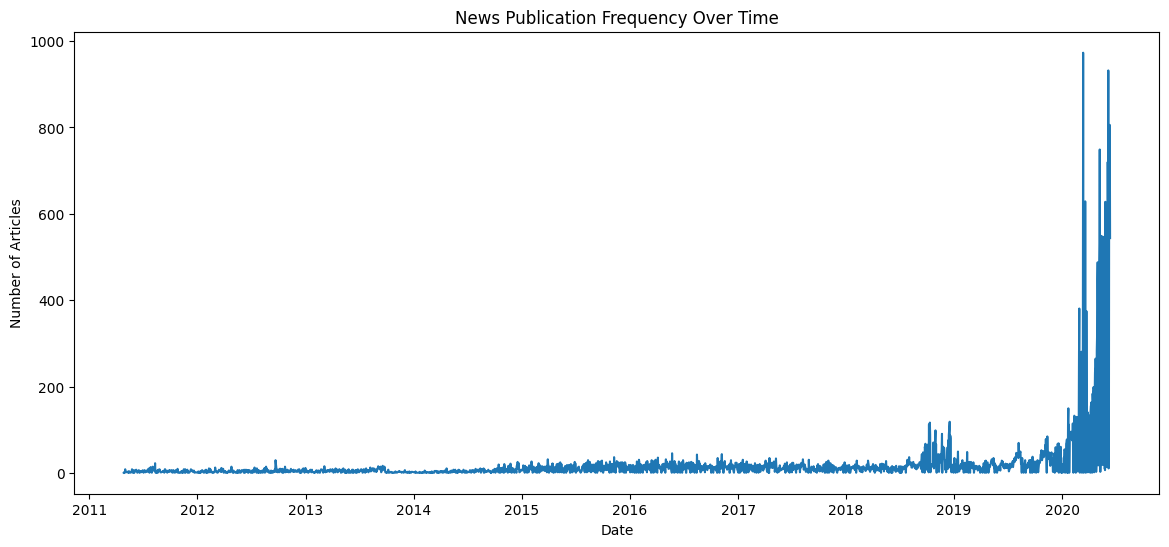

In [78]:
plt.figure(figsize=(14,6))

daily_articles.plot()

plt.title("News Publication Frequency Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

TEXT ANALYSIS (TOPIC MODELING)

In [79]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

data['clean_headline'] = data['headline'].astype(str).apply(clean_text)

data[['headline', 'clean_headline']].head()

[nltk_data] Downloading package stopwords to /Users/selam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks hit week highs friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks hit week highs wednesday
2,71 Biggest Movers From Friday,biggest movers friday
3,46 Stocks Moving In Friday's Mid-Day Session,stocks moving fridays midday session
4,B of A Securities Maintains Neutral on Agilent...,b securities maintains neutral agilent technol...


In [81]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=20)

X = vectorizer.fit_transform(data['clean_headline'])

word_counts = X.toarray().sum(axis=0)

words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'count': word_counts
})

word_freq = word_freq.sort_values(by='count', ascending=False)

print(word_freq)

          word   count
18          vs  162147
14      stocks  161868
6          est  140606
5          eps  128929
13      shares  114209
11     reports  108707
17      update   91680
7       market   90880
4     earnings   87185
12       sales   79526
15         top   78678
9           pt   73054
19        week   67669
0    announces   66529
8        price   64232
2          buy   64060
3   downgrades   61942
16     trading   61158
1    benzingas   57985
10      raises   57798


In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X_tfidf = tfidf.fit_transform(data['clean_headline'])

scores = X_tfidf.toarray().sum(axis=0)

terms = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame({
    'term': terms,
    'score': scores
})

tfidf_df = tfidf_df.sort_values(
    by='score',
    ascending=False
)

print(tfidf_df)

          term          score
14      stocks  134486.207447
13      shares   78919.827672
4     earnings   75443.722461
7       market   67034.338189
16      update   65887.230090
18          vs   65489.651062
11     reports   64179.732262
5          eps   61322.242573
0    announces   55608.172528
19        week   53963.087039
6          est   53594.004800
8        price   50436.945785
9           pt   49511.030004
1    benzingas   47712.674210
3   downgrades   46922.823826
12       sales   46247.211718
2          buy   44387.836919
15     trading   43682.996311
17    upgrades   39587.167255
10      raises   39082.554179


In [84]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['headline'])

bigram_counts = X_bigram.toarray().sum(axis=0)

bigrams = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    'bigram': bigrams,
    'count': bigram_counts
})

bigram_df = bigram_df.sort_values(
    by='count',
    ascending=False
)

print(bigram_df)

                bigram  count
0              52 week  51006
10        price target  47274
16       stocks moving  40044
8              mid day  37324
7        market update  33101
4   earnings scheduled  32055
5   initiates coverage  28993
9           pre market  28393
14           raises pt  27213
3    companies trading  23170
17      trading higher  22700
6       market session  22428
19              vs est  21843
1              adj eps  21708
2    benzinga upgrades  21108
11              q1 eps  20704
12              q2 eps  20258
13              q3 eps  20043
15          stocks hit  20030
18       trading lower  20018


In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X_tfidf = tfidf.fit_transform(data['clean_headline'])

scores = X_tfidf.toarray().sum(axis=0)

terms = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame({
    'term': terms,
    'score': scores
})

tfidf_df = tfidf_df.sort_values(
    by='score',
    ascending=False
)

print(tfidf_df)

          term          score
14      stocks  134486.207447
13      shares   78919.827672
4     earnings   75443.722461
7       market   67034.338189
16      update   65887.230090
18          vs   65489.651062
11     reports   64179.732262
5          eps   61322.242573
0    announces   55608.172528
19        week   53963.087039
6          est   53594.004800
8        price   50436.945785
9           pt   49511.030004
1    benzingas   47712.674210
3   downgrades   46922.823826
12       sales   46247.211718
2          buy   44387.836919
15     trading   43682.996311
17    upgrades   39587.167255
10      raises   39082.554179


## TIME SERIES ANALYSIS


In [86]:
# Extract only the date part
data['publication_day'] = data['date'].dt.date

# Count articles per day
daily_news = data.groupby('publication_day').size()

daily_news.head()

publication_day
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

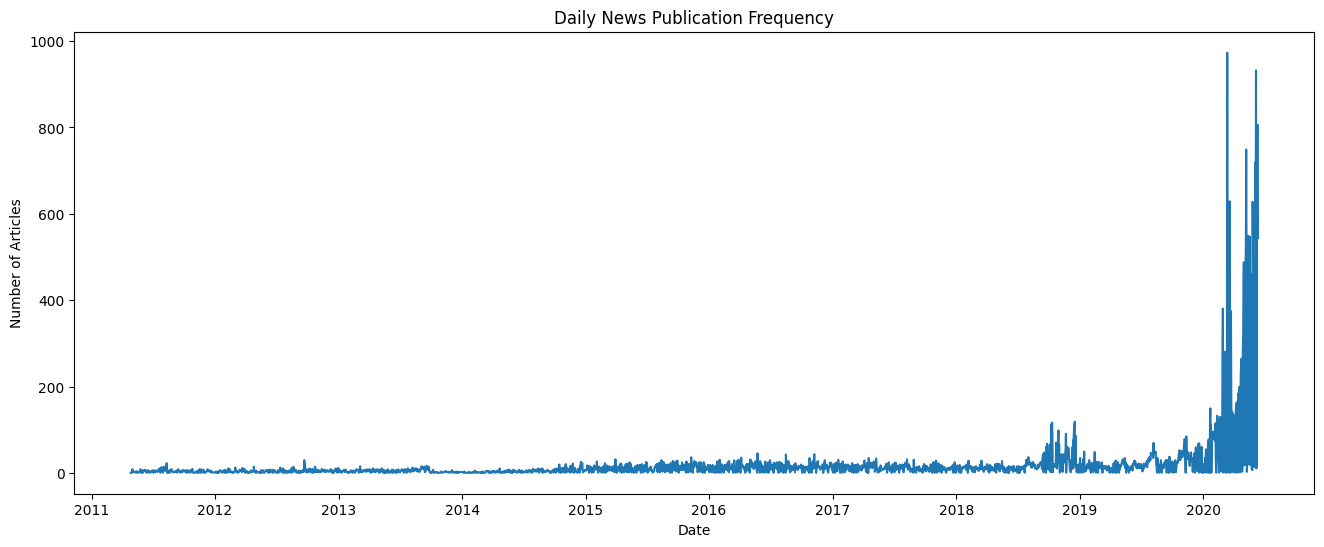

In [87]:
plt.figure(figsize=(16,6))

daily_news.plot()

plt.title("Daily News Publication Frequency")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [88]:
# Top 10 days with highest article volume
spikes = daily_news.sort_values(ascending=False).head(10)

print(spikes)

publication_day
2020-03-12    973
2020-06-05    932
2020-06-10    806
2020-06-09    804
2020-06-08    765
2020-05-07    749
2020-06-03    720
2020-03-19    629
2020-05-26    628
2020-05-13    549
dtype: int64


In [89]:
# Replace with one of the spike dates you found
spike_date = '2020-03-16'

spike_articles = data[
    data['publication_day'].astype(str) == spike_date
]

spike_articles[['headline', 'publisher', 'stock']].head(20)

,headline,publisher,stock
5321,Stocks That Hit 52-Week Lows On Monday,Benzinga Newsdesk,AAOI
5739,144 Biggest Movers From Friday,Lisa Levin,AAON
9678,Stocks That Hit 52-Week Lows On Monday,Benzinga Newsdesk,ABCB
10501,Stocks That Hit 52-Week Lows On Monday,Benzinga Newsdesk,ABM
13319,Stocks That Hit 52-Week Lows On Monday,Benzinga Newsdesk,ACCO
14334,Stocks That Hit 52-Week Lows On Monday,Benzinga Newsdesk,ACH
19279,20 Healthcare Stocks Moving In Monday's Pre-Ma...,Benzinga Newsdesk,ACST
23962,Advanced Emissions Solns Q4 Sales $16M May Not...,Benzinga Newsdesk,ADES
23963,"Earnings Scheduled For March 16, 2020",Lisa Levin,ADES
46100,AGTC Announces Completion of Enrollment in All...,Benzinga Newsdesk,AGTC


In [90]:
data['year_month'] = data['date'].dt.to_period('M')

monthly_news = data.groupby('year_month').size()

monthly_news.head()

/var/folders/xs/zq2078pd61l68rrzh14wczj00000gp/T/ipykernel_27043/32167307.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['year_month'] = data['date'].dt.to_period('M')


year_month
2011-04      6
2011-05     78
2011-06     96
2011-07    137
2011-08    149
Freq: M, dtype: int64

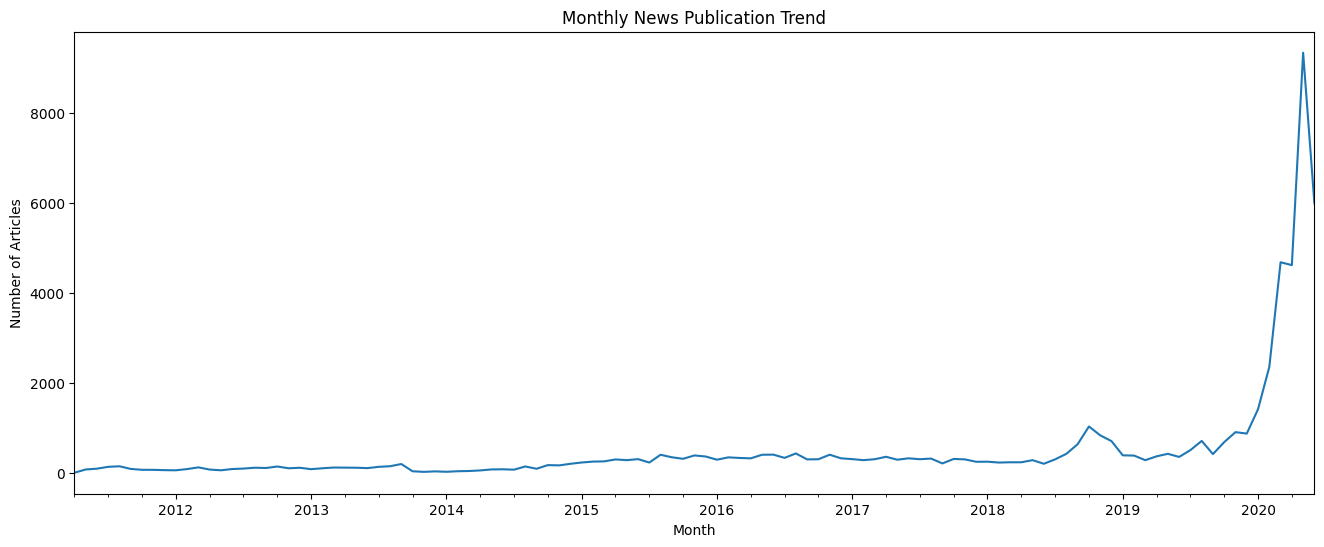

In [91]:
plt.figure(figsize=(16,6))

monthly_news.plot()

plt.title("Monthly News Publication Trend")
plt.xlabel("Month")
plt.ylabel("Number of Articles")

plt.show()

In [92]:
# Extract hour from timestamp
data['hour'] = data['date'].dt.hour

hourly_news = data['hour'].value_counts().sort_index()

hourly_news

hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

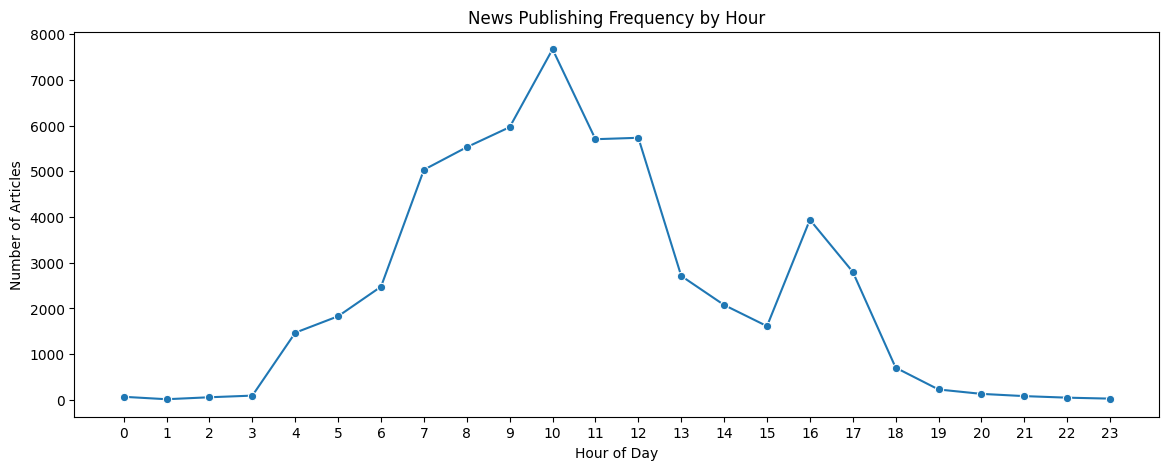

In [93]:
plt.figure(figsize=(14,5))

sns.lineplot(
    x=hourly_news.index,
    y=hourly_news.values,
    marker='o'
)

plt.title("News Publishing Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.xticks(range(0,24))

plt.show()

In [94]:
data['day_name'] = data['date'].dt.day_name()

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_counts = data['day_name'].value_counts().reindex(day_order)

day_counts

day_name
Monday       10322
Tuesday      11002
Wednesday    11891
Thursday     12688
Friday        9381
Saturday       267
Sunday         436
Name: count, dtype: int64

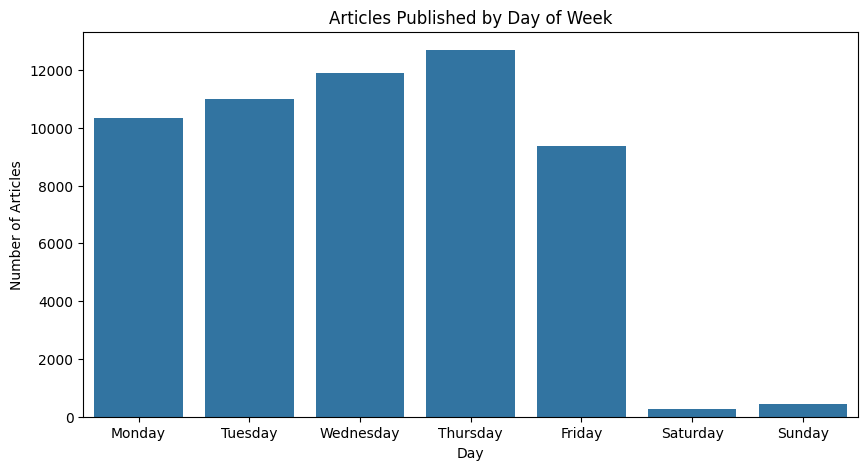

In [95]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=day_counts.index,
    y=day_counts.values
)

plt.title("Articles Published by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Articles")

plt.show()

In [96]:
most_active_hour = hourly_news.idxmax()

print(f"Most news articles are published around {most_active_hour}:00.")

Most news articles are published around 10.0:00.


## PUBLISHER ANALYSIS

In [97]:
publisher_counts = data['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

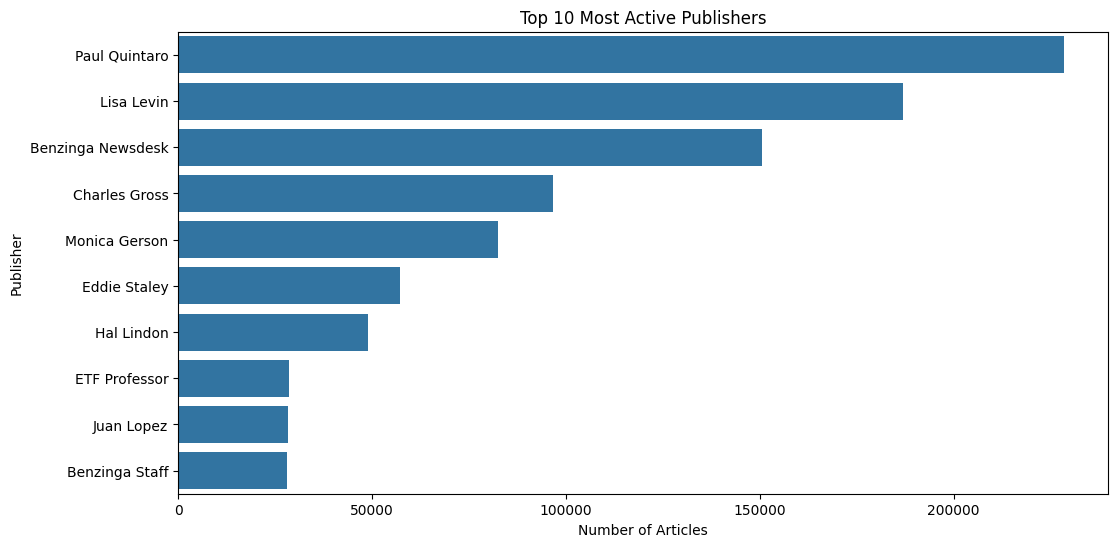

In [98]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Top 10 Most Active Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

In [99]:
publisher_percentage = (
    data['publisher']
    .value_counts(normalize=True)
    .head(10) * 100
)

publisher_percentage

publisher
Paul Quintaro        16.227418
Lisa Levin           13.286100
Benzinga Newsdesk    10.692888
Charles Gross         6.873451
Monica Gerson         5.853646
Eddie Staley          4.068277
Hal Lindon            3.485115
ETF Professor         2.024333
Juan Lopez            2.020709
Benzinga Staff        1.997686
Name: proportion, dtype: float64

In [100]:
top_publisher = publisher_counts.index[0]

print("Top Publisher:", top_publisher)

data[data['publisher'] == top_publisher][
    ['headline', 'stock']
].head(10)

Top Publisher: Paul Quintaro


,headline,stock
209,"Agilent Reports Purchase Of Genohm, No Terms D...",A
212,"UPDATE: Alnylam, Agilent Deal Has Initial Term...",A
213,Alnylam Pharma 8-K Shows Co. Entered Manufactu...,A
225,Agilent Reports Purchase Of Luxcel Biosciences...,A
233,Agilent Sees Q1 Adj. EPS $0.55-$0.57 vs $0.60 ...,A
234,Agilent Sees FY18 Adj. EPS $2.50-$2.56 vs $2.5...,A
235,Agilent Reports Q4 Adj. EPS $0.67 vs $0.62 Est...,A
241,Agilent Reports Dako PD-L1 IHC 28-8 PharmDx Ap...,A
242,Agilent Reports FDA Approval Of GenetiSure Dx ...,A
255,Wells Fargo Upgrades Agilent Technologies to O...,A


In [101]:
# Find rows containing email addresses
email_publishers = data[
    data['publisher'].str.contains('@', na=False)
]

email_publishers[['publisher']].head()

,publisher
5,vishwanath@benzinga.com
6,vishwanath@benzinga.com
8,vishwanath@benzinga.com
11,vishwanath@benzinga.com
22,vishwanath@benzinga.com


In [102]:
def extract_domain(email):
    
    match = re.search(r'@([\w.-]+)', str(email))
    
    if match:
        return match.group(1)
    
    return None

email_publishers['domain'] = email_publishers[
    'publisher'
].apply(extract_domain)

email_publishers[['publisher', 'domain']].head()

,publisher,domain
5,vishwanath@benzinga.com,benzinga.com
6,vishwanath@benzinga.com,benzinga.com
8,vishwanath@benzinga.com,benzinga.com
11,vishwanath@benzinga.com,benzinga.com
22,vishwanath@benzinga.com,benzinga.com


In [103]:
domain_counts = email_publishers['domain'].value_counts()

domain_counts.head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

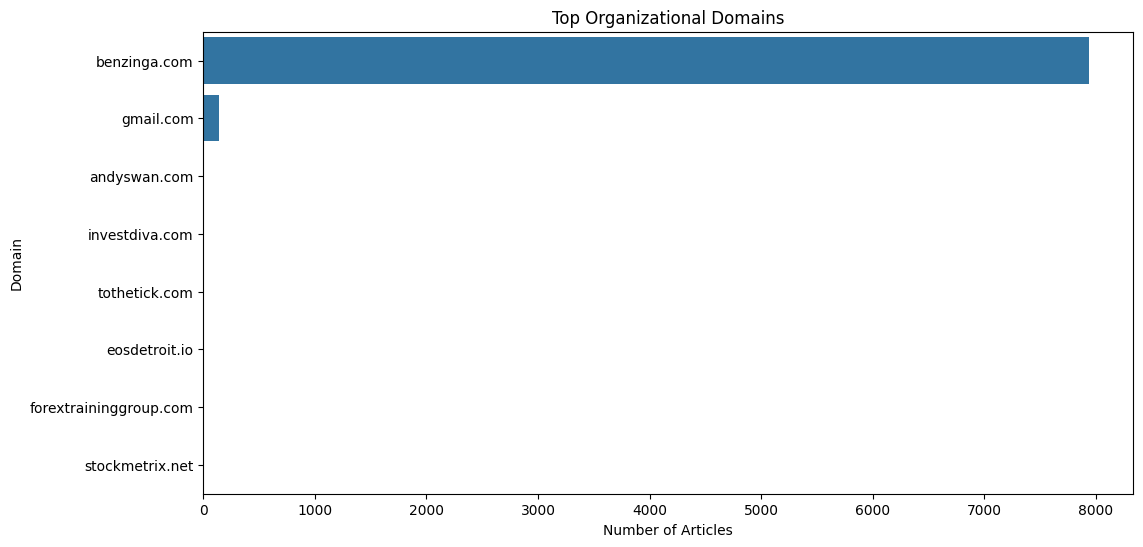

In [104]:
top_domains = domain_counts.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_domains.values,
    y=top_domains.index
)

plt.title("Top Organizational Domains")
plt.xlabel("Number of Articles")
plt.ylabel("Domain")

plt.show()

In [105]:
# Crosstab of publishers vs stocks
publisher_stock = pd.crosstab(
    data['publisher'],
    data['stock']
)

publisher_stock.head()

stock,A,AA,AAC,AADR,AAL,AAMC,AAME,AAN,AAOI,AAON,...,ZOES,ZPIN,ZQK,ZSL,ZSPH,ZTR,ZTS,ZU,ZUMZ,ZX
publisher,,,,,,,,,,,,,,,,,,,,,
47ertrends,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AARP,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABNNewswire,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aakin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aaron Jackson.Ed,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [106]:
top_publisher_stocks = data[
    data['publisher'] == top_publisher
]['stock'].value_counts().head(10)

top_publisher_stocks

stock
XRT     571
AGN     561
JCP     557
EBAY    539
VZ      530
BBRY    522
P       503
MRK     500
JNJ     495
QCOM    487
Name: count, dtype: int64

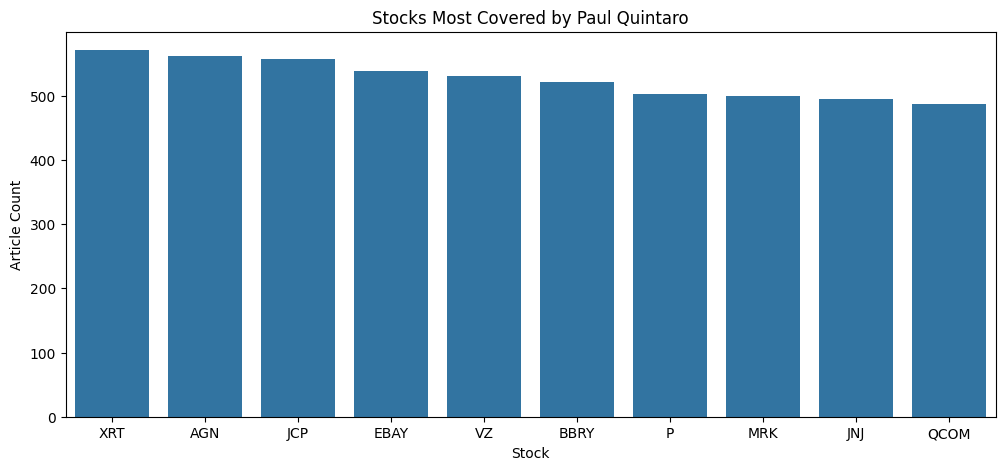

In [107]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_publisher_stocks.index,
    y=top_publisher_stocks.values
)

plt.title(f"Stocks Most Covered by {top_publisher}")
plt.xlabel("Stock")
plt.ylabel("Article Count")

plt.show()